# Association Rule Mining with `mlxtend`

This notebook is inspired by the official `mlxtend` association-rules tutorial:

- https://rasbt.github.io/mlxtend/user_guide/frequent_patterns/association_rules/

In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt

from mlxtend import __version__ as mlxtend_version
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

print("Python executable:", sys.executable)
print("mlxtend version:", mlxtend_version)


Python executable: /opt/anaconda3/envs/L2D/bin/python
mlxtend version: 0.24.0


## Conceptual background

An **association rule** has the form $A \Rightarrow C$, where:

- $A$ is the **antecedent**,
- $C$ is the **consequent**,
- and the two itemsets are disjoint.

A rule such as `{Onion} -> {Eggs}` is often interpreted as: *transactions containing Onion also tend to contain Eggs*.

The official `mlxtend` guide emphasizes that a rule is not judged only by whether it exists, but also by how interesting it is according to summary metrics:

- **support**: how often the combined itemset appears;
- **confidence**: how often the consequent appears when the antecedent appears;
- **lift**: how much more often antecedent and consequent occur together than expected under independence;
- **leverage** and **conviction**: alternative measures of dependence that highlight different aspects of rule quality.

Different metrics encode different research priorities: prevalence, reliability, surprisingness, or deviation from independence.


## A toy market-basket dataset


In [2]:
dataset = [
    ["Milk", "Onion", "Nutmeg", "Kidney Beans", "Eggs", "Yogurt"],
    ["Dill", "Onion", "Nutmeg", "Kidney Beans", "Eggs", "Yogurt"],
    ["Milk", "Apple", "Kidney Beans", "Eggs"],
    ["Milk", "Unicorn", "Corn", "Kidney Beans", "Yogurt"],
    ["Corn", "Onion", "Onion", "Kidney Beans", "Ice cream", "Eggs"],
]

for i, transaction in enumerate(dataset, start=1):
    print(f"Transaction {i}: {transaction}")


Transaction 1: ['Milk', 'Onion', 'Nutmeg', 'Kidney Beans', 'Eggs', 'Yogurt']
Transaction 2: ['Dill', 'Onion', 'Nutmeg', 'Kidney Beans', 'Eggs', 'Yogurt']
Transaction 3: ['Milk', 'Apple', 'Kidney Beans', 'Eggs']
Transaction 4: ['Milk', 'Unicorn', 'Corn', 'Kidney Beans', 'Yogurt']
Transaction 5: ['Corn', 'Onion', 'Onion', 'Kidney Beans', 'Ice cream', 'Eggs']


## One-hot encoding with `TransactionEncoder`

Frequent-pattern algorithms in `mlxtend` expect a binary transaction matrix: rows are transactions, columns are items, and the entries indicate presence or absence.

`TransactionEncoder` converts the raw basket representation into exactly that format.


In [3]:
te = TransactionEncoder()
te_array = te.fit(dataset).transform(dataset)
df = pd.DataFrame(te_array, columns=te.columns_)
df


,Apple,Corn,Dill,Eggs,Ice cream,Kidney Beans,Milk,Nutmeg,Onion,Unicorn,Yogurt
0,False,False,False,True,False,True,True,True,True,False,True
1,False,False,True,True,False,True,False,True,True,False,True
2,True,False,False,True,False,True,True,False,False,False,False
3,False,True,False,False,False,True,True,False,False,True,True
4,False,True,False,True,True,True,False,False,True,False,False


A useful observation is that this table is now ready for several frequent-pattern algorithms. The tutorial mentions `apriori`, `fpgrowth`, and `fpmax`. In classroom settings, it is often helpful to remember the following conceptual distinction:

- `apriori` is historically important and very interpretable;
- `fpgrowth` is often faster because it avoids generating as many candidate itemsets explicitly;
- `fpmax` returns only **maximal** frequent itemsets.

For our main walkthrough we will use `fpgrowth`, just as in the official guide.


## Frequent itemsets

A frequent itemset is an itemset whose support exceeds a chosen threshold. Here we set `min_support=0.6`, which means an itemset must appear in at least 60% of the transactions.

Because our dataset has only 5 transactions, a support of `0.6` means *at least 3 transactions*.


In [4]:
frequent_itemsets = fpgrowth(df, min_support=0.6, use_colnames=True)
frequent_itemsets.sort_values("support", ascending=False)


,support,itemsets
0,1.0,frozenset({Kidney Beans})
1,0.8,frozenset({Eggs})
5,0.8,"frozenset({Kidney Beans, Eggs})"
2,0.6,frozenset({Yogurt})
3,0.6,frozenset({Onion})
4,0.6,frozenset({Milk})
6,0.6,"frozenset({Kidney Beans, Yogurt})"
7,0.6,"frozenset({Eggs, Onion})"
8,0.6,"frozenset({Kidney Beans, Onion})"
9,0.6,"frozenset({Kidney Beans, Eggs, Onion})"


For completeness, let us verify that `apriori` gives the same frequent itemsets on this tiny example.


In [5]:
frequent_itemsets_apriori = apriori(df, min_support=0.6, use_colnames=True)
comparison = frequent_itemsets.merge(
    frequent_itemsets_apriori,
    on=["support", "itemsets"],
    how="outer",
    indicator=True,
)
comparison


,support,itemsets,_merge
0,0.6,frozenset({Yogurt}),both
1,0.6,frozenset({Onion}),both
2,0.6,frozenset({Milk}),both
3,0.6,"frozenset({Kidney Beans, Yogurt})",both
4,0.6,"frozenset({Eggs, Onion})",both
5,0.6,"frozenset({Kidney Beans, Onion})",both
6,0.6,"frozenset({Kidney Beans, Eggs, Onion})",both
7,0.6,"frozenset({Kidney Beans, Milk})",both
8,0.8,frozenset({Eggs}),both
9,0.8,"frozenset({Kidney Beans, Eggs})",both


If all rows are marked as `both`, the two algorithms agree on the discovered frequent itemsets for this support threshold.

This is an important conceptual point: different algorithms may differ in efficiency, but they are solving the same underlying frequent-itemset problem.


## Generating rules with a confidence threshold

Now we move from itemsets to rules. The official tutorial shows the `association_rules` function with a confidence threshold. We follow the same idea here.

The argument `num_itemsets=len(df.index)` tells the function how many transactions were used to compute the supports.


In [6]:
rules_conf = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.7,
    num_itemsets=len(df.index),
)

columns_to_show = [
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift",
    "leverage",
    "conviction",
]

rules_conf[columns_to_show].sort_values(["confidence", "lift"], ascending=False)


/opt/anaconda3/envs/L2D/lib/python3.14/site-packages/mlxtend/frequent_patterns/association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


,antecedents,consequents,support,confidence,lift,leverage,conviction
4,frozenset({Onion}),frozenset({Eggs}),0.6,1.00,1.25,0.12,inf
7,"frozenset({Kidney Beans, Onion})",frozenset({Eggs}),0.6,1.00,1.25,0.12,inf
10,frozenset({Onion}),"frozenset({Kidney Beans, Eggs})",0.6,1.00,1.25,0.12,inf
1,frozenset({Eggs}),frozenset({Kidney Beans}),0.8,1.00,1.00,0.00,inf
2,frozenset({Yogurt}),frozenset({Kidney Beans}),0.6,1.00,1.00,0.00,inf
5,frozenset({Onion}),frozenset({Kidney Beans}),0.6,1.00,1.00,0.00,inf
8,"frozenset({Eggs, Onion})",frozenset({Kidney Beans}),0.6,1.00,1.00,0.00,inf
11,frozenset({Milk}),frozenset({Kidney Beans}),0.6,1.00,1.00,0.00,inf
0,frozenset({Kidney Beans}),frozenset({Eggs}),0.8,0.80,1.00,0.00,1.0
3,frozenset({Eggs}),frozenset({Onion}),0.6,0.75,1.25,0.12,1.6


### Interpreting the metrics

- A rule can have **high confidence** simply because the consequent is already common.
- **Lift** helps correct for that by comparing the observed co-occurrence to what independence would predict.
- **Leverage** measures the absolute difference from independence, which can be useful when you care about effect size rather than relative effect.
- **Conviction** becomes very large when confidence approaches 1 and counterexamples become rare.

This is why in practice analysts often inspect multiple metrics together.


## Using a different metric: lift

Rule mining is not only about generating rules, but also about deciding what “interesting” means for your application.


In [7]:
rules_lift = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1.2,
    num_itemsets=len(df.index),
)

rules_lift[columns_to_show].sort_values(["lift", "confidence"], ascending=False)


,antecedents,consequents,support,confidence,lift,leverage,conviction
1,frozenset({Onion}),frozenset({Eggs}),0.6,1.00,1.25,0.12,inf
3,"frozenset({Kidney Beans, Onion})",frozenset({Eggs}),0.6,1.00,1.25,0.12,inf
5,frozenset({Onion}),"frozenset({Kidney Beans, Eggs})",0.6,1.00,1.25,0.12,inf
0,frozenset({Eggs}),frozenset({Onion}),0.6,0.75,1.25,0.12,1.6
2,"frozenset({Kidney Beans, Eggs})",frozenset({Onion}),0.6,0.75,1.25,0.12,1.6
4,frozenset({Eggs}),"frozenset({Kidney Beans, Onion})",0.6,0.75,1.25,0.12,1.6


In [8]:
rules_lift = rules_lift.copy()
rules_lift["antecedent_len"] = rules_lift["antecedents"].apply(len)

filtered_rules = rules_lift[
    (rules_lift["antecedent_len"] >= 2)
    & (rules_lift["confidence"] > 0.75)
    & (rules_lift["lift"] > 1.2)
]

filtered_rules[columns_to_show + ["antecedent_len"]]


,antecedents,consequents,support,confidence,lift,leverage,conviction,antecedent_len
3,"frozenset({Kidney Beans, Onion})",frozenset({Eggs}),0.6,1.0,1.25,0.12,inf,2


In [9]:
rules_lift[rules_lift["antecedents"] == {"Eggs", "Kidney Beans"}][columns_to_show + ["antecedent_len"]]


,antecedents,consequents,support,confidence,lift,leverage,conviction,antecedent_len
2,"frozenset({Kidney Beans, Eggs})",frozenset({Onion}),0.6,0.75,1.25,0.12,1.6,2


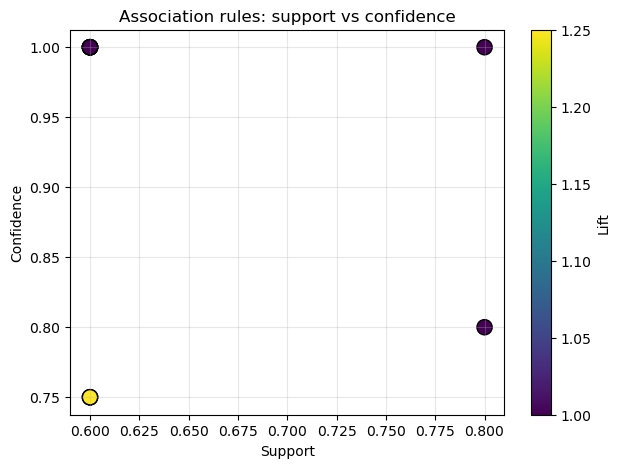

In [10]:
plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    rules_conf["support"],
    rules_conf["confidence"],
    c=rules_conf["lift"],
    cmap="viridis",
    s=120,
    edgecolor="black",
)
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Association rules: support vs confidence")
plt.colorbar(scatter, label="Lift")
plt.grid(alpha=0.3)
plt.show()


## Incomplete frequent-itemset tables and `support_only=True`

The tutorial includes an important edge case: sometimes the frequent-itemset table is incomplete, meaning that some supports needed to compute confidence or lift are not available.

In that case, `association_rules(..., support_only=True)` still lets us recover the support of candidate rules while assigning `NaN` to metrics that cannot be computed reliably.


In [11]:
freq_itemsets_incomplete = pd.DataFrame(
    {
        "itemsets": [
            ["177", "176"],
            ["177", "179"],
            ["176", "178"],
            ["176", "179"],
            ["93", "100"],
            ["177", "178"],
            ["177", "176", "178"],
        ],
        "support": [0.253623, 0.253623, 0.217391, 0.217391, 0.181159, 0.108696, 0.108696],
    }
)

freq_itemsets_incomplete


,itemsets,support
0,"[177, 176]",0.253623
1,"[177, 179]",0.253623
2,"[176, 178]",0.217391
3,"[176, 179]",0.217391
4,"[93, 100]",0.181159
5,"[177, 178]",0.108696
6,"[177, 176, 178]",0.108696


In [12]:
rules_support_only = association_rules(
    freq_itemsets_incomplete,
    support_only=True,
    min_threshold=0.1,
    num_itemsets=0,
)

rules_support_only[["antecedents", "consequents", "support"]]


,antecedents,consequents,support
0,frozenset({176}),frozenset({177}),0.253623
1,frozenset({177}),frozenset({176}),0.253623
2,frozenset({179}),frozenset({177}),0.253623
3,frozenset({177}),frozenset({179}),0.253623
4,frozenset({176}),frozenset({178}),0.217391
5,frozenset({178}),frozenset({176}),0.217391
6,frozenset({179}),frozenset({176}),0.217391
7,frozenset({176}),frozenset({179}),0.217391
8,frozenset({93}),frozenset({100}),0.181159
9,frozenset({100}),frozenset({93}),0.181159


## Rule pruning with the pandas API

There is no special pruning function: we simply remove rows from the rules dataframe according to our research criteria.


In [13]:
pruned_rules = rules_lift[rules_lift["consequents"].apply(len) == 1]
pruned_rules[columns_to_show + ["antecedent_len"]]


,antecedents,consequents,support,confidence,lift,leverage,conviction,antecedent_len
0,frozenset({Eggs}),frozenset({Onion}),0.6,0.75,1.25,0.12,1.6,1
1,frozenset({Onion}),frozenset({Eggs}),0.6,1.00,1.25,0.12,inf,1
2,"frozenset({Kidney Beans, Eggs})",frozenset({Onion}),0.6,0.75,1.25,0.12,1.6,2
3,"frozenset({Kidney Beans, Onion})",frozenset({Eggs}),0.6,1.00,1.25,0.12,inf,2
